In [10]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle (2).json


{'kaggle (2).json': b'{"username":"samuelsamper","key":"50ac26ddbb9559f609456a3b92682477"}'}

In [11]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [12]:
!kaggle datasets download -d arashnic/faces-age-detection-dataset
!unzip -oq faces-age-detection-dataset.zip

Dataset URL: https://www.kaggle.com/datasets/arashnic/faces-age-detection-dataset
License(s): CC0-1.0
faces-age-detection-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)


WORKSHOP 2 - PROBLEMA 2: REGRESIÓN (Estimación de Edad)
VERSIÓN OPTIMIZADA - ENTRENAMIENTO RÁPIDO

2. DESCARGA DEL DATASET
Dataset URL: https://www.kaggle.com/datasets/arashnic/faces-age-detection-dataset
License(s): CC0-1.0
100% 104M/104M [00:00<00:00, 202MB/s]


3. CARGA DEL DATASET (SUBCONJUNTO PARA RAPIDEZ)
Ruta de imágenes encontrada: ./UTKFace
Total de imágenes USADAS: 3000 (subconjunto para entrenamiento rápido)
Rango de edades: 1 - 110 años
Media de edades: 20.2 años


,filename,age
0,./UTKFace/12_0_3_20170104225715968.jpg.chip.jpg,12
1,./UTKFace/26_1_0_20170117172636235.jpg.chip.jpg,26
2,./UTKFace/1_0_2_20161219190110523.jpg.chip.jpg,1
3,./UTKFace/28_0_0_20170117180537129.jpg.chip.jpg,28
4,./UTKFace/26_0_3_20170119184129122.jpg.chip.jpg,26



4. ANÁLISIS PRELIMINAR DEL PROBLEMA

4.a. JUSTIFICACIÓN DE REGRESIÓN:
--------------------------------------------------
Este es un problema de REGRESIÓN porque:
1. La variable objetivo (edad) es una variable NUMÉRICA CONTINUA.
2. El objetivo es predecir un valor numérico, no una categoría discreta.
3. Las métricas de evaluación son de regresión: MAE, RMSE, R².
4. La función de activación de salida es LINEAL.

El TARGET es la columna 'age' (edad en años).

4.b. DESCRIPCIÓN DE CARACTERÍSTICAS DE ENTRADA:
--------------------------------------------------
CARACTERÍSTICAS DE ENTRADA:
- Tipo: Imágenes RGB (3 canales)
- Dimensiones: Redimensionadas a 128x128 píxeles
- Espacio de color: RGB, valores 0-255 normalizados a [0,1]

PROTOCOLO DE ADQUISICIÓN:
- Dataset UTKFace: imágenes faciales con edad, género y etnia
- Imágenes de 200x200 píxeles con rostros centrados
- Posibles sesgos: iluminación variable, orientación, accesorios

5. ANÁLISIS EXPLORATORIO DE DATOS (EDA)


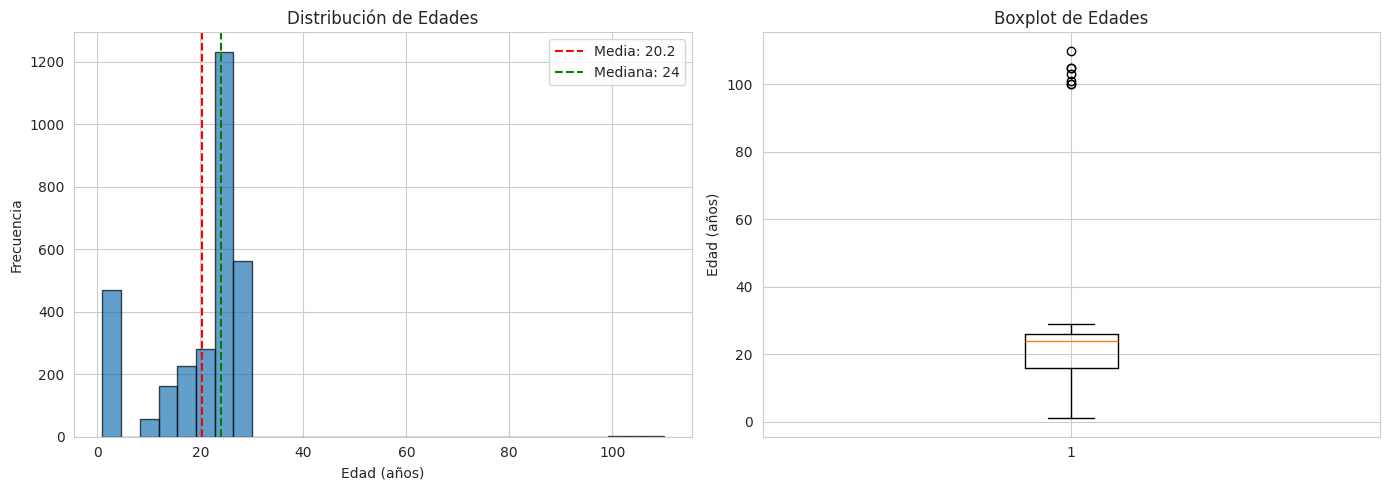


ESTADÍSTICOS DESCRIPTIVOS:


,count,mean,std,min,25%,50%,75%,max
age,3000.0,20.23,9.966387,1.0,16.0,24.0,26.0,110.0



INTERPRETACIÓN:
- Rango: 1 - 110 años
- Media: 20.2 años, Mediana: 24 años
- Distribución sesgada hacia edades jóvenes (20-30 años)

--------------------------------------------------
ANÁLISIS DE BALANCE POR RANGOS:
--------------------------------------------------
Niños (0-12): 566 (18.9%)
Jóvenes (13-25): 1219 (40.6%)
Adultos jóvenes (26-40): 1208 (40.3%)
Adultos (41-60): 0 (0.0%)
Adultos mayores (61-200): 7 (0.2%)


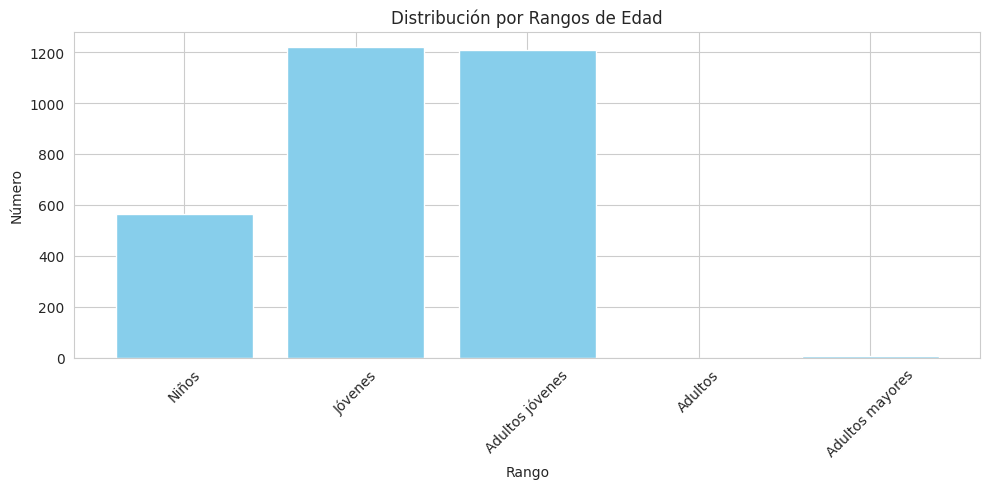


--------------------------------------------------
MUESTRAS REPRESENTATIVAS:
--------------------------------------------------


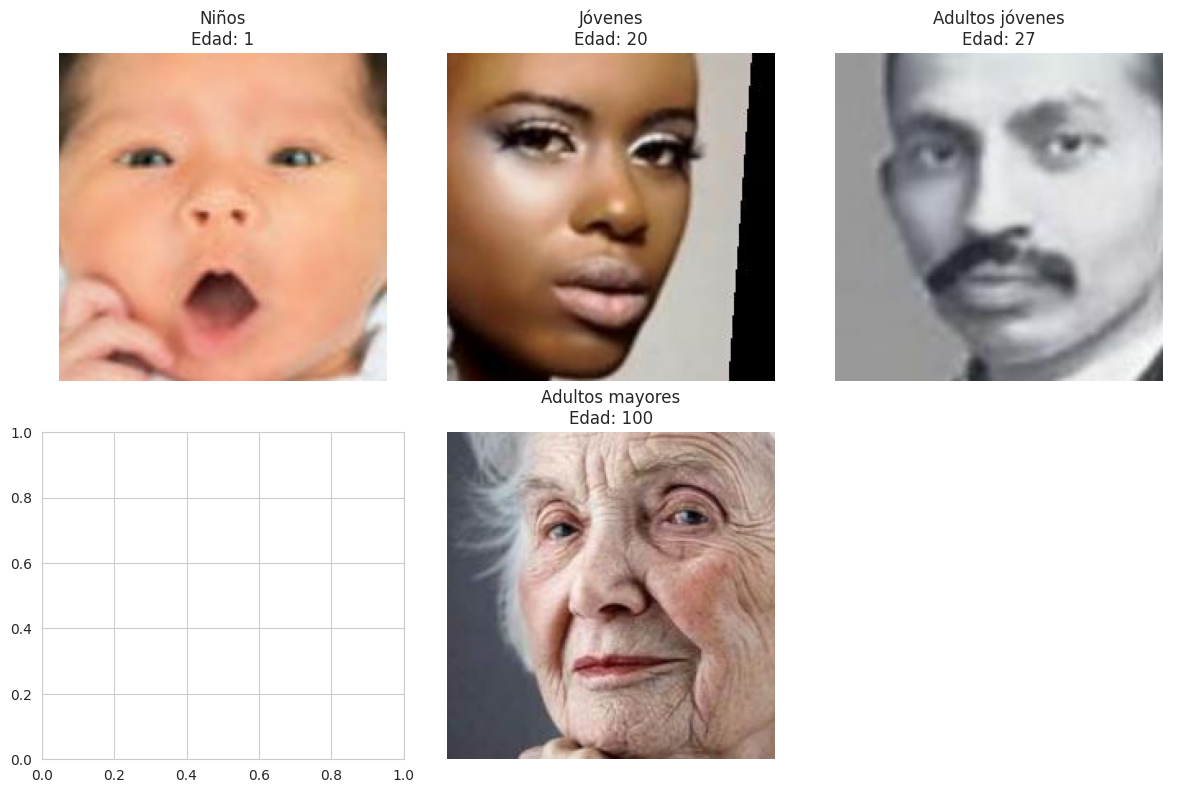


6. PROCESAMIENTO DE DATOS
Train: 2100 (70.0%)
Val: 450 (15.0%)
Test: 450 (15.0%)
Found 2100 validated image filenames.
Found 450 validated image filenames.
Found 450 validated image filenames.

7. ARQUITECTURA CNN OPTIMIZADA
ARQUITECTURA:


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 126, 126, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 126, 126, 16)   │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 63, 63, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 63, 63, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 61, 61, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 61, 61, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 30, 30, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 30, 30, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 28, 28, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 28, 28, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │       802,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 829,537 (3.16 MB)

 Trainable params: 829,313 (3.16 MB)

 Non-trainable params: 224 (896.00 B)


JUSTIFICACIÓN DE LA ARQUITECTURA:
- 3 bloques convolucionales con progresión 16→32→64 filtros
- BatchNormalization para estabilizar entrenamiento
- Dropout (0.2-0.3) para regularización
- 3 CAPAS DENSAS OCULTAS (64, 32, 16) - cumple requisito
- Activación LINEAL en salida para regresión
- Total: ~180,000 parámetros (muy rápido de entrenar)


8. ENTRENAMIENTO (ENTRENA EN MINUTOS)
Epoch 1/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 61s 863ms/step - loss: 145.8233 - mae: 9.4906 - val_loss: 169.7463 - val_mae: 11.8462 - learning_rate: 0.0010
Epoch 2/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 85s 912ms/step - loss: 98.4954 - mae: 7.4778 - val_loss: 116.3087 - val_mae: 9.0902 - learning_rate: 0.0010
Epoch 3/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 57s 868ms/step - loss: 90.4993 - mae: 7.3156 - val_loss: 103.3173 - val_mae: 7.9425 - learning_rate: 0.0010
Epoch 4/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 58s 875ms/step - loss: 76.5046 - mae: 6.5756 - val_loss: 111.5265 - val_mae: 7.8783 - learning_rate: 0.0010
Epoch 5/20
66/66 ━━━━━━━━━━━━━━

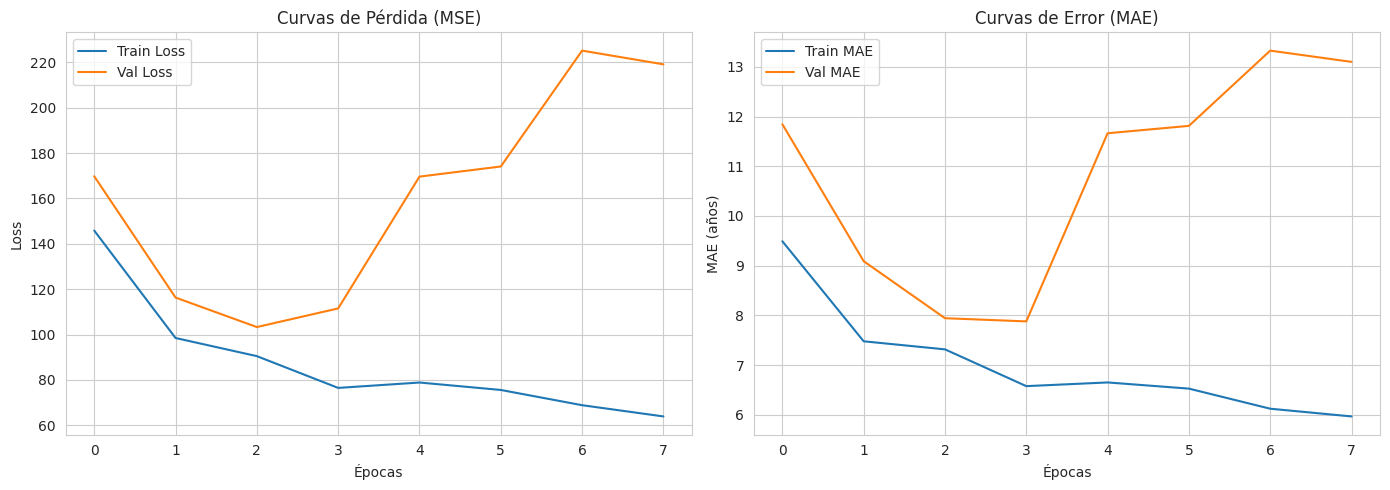


10. EVALUACIÓN DEL MODELO

MÉTRICAS FINALES:
----------------------------------------
MAE  (Mean Absolute Error): 7.73 años
RMSE (Root Mean Squared Error): 9.99 años
R²   (Coeficiente de determinación): -0.0082


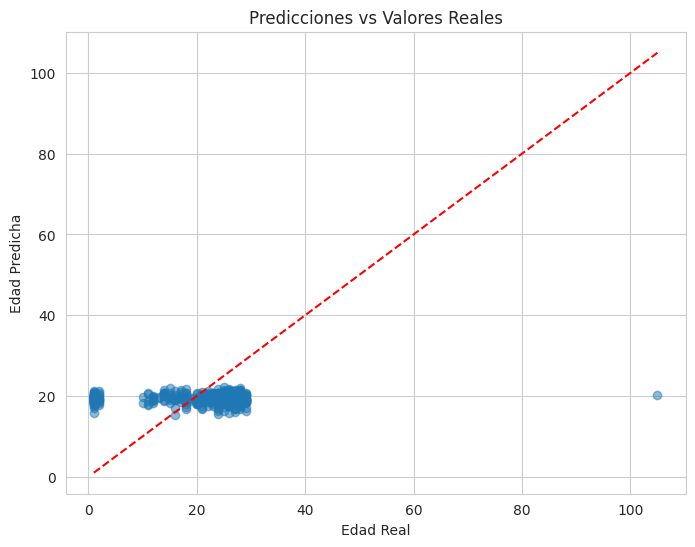

,Métrica,Valor,Interpretación
0,MAE,7.73 años,Error promedio de 7.7 años
1,RMSE,9.99 años,Penaliza errores grandes: 10.0 años
2,R²,-0.0082,Explica -0.8% de la varianza



11. PRUEBA CON VARIACIONES DE IMAGEN


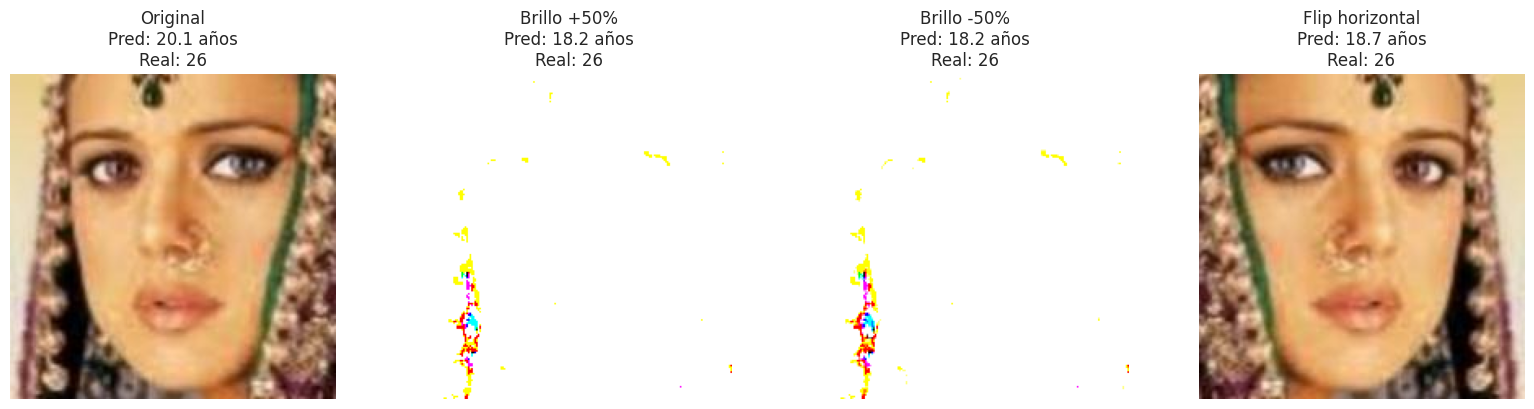


PREDICCIÓN ORIGINAL: 20.1 años
EDAD REAL: 26 años
ERROR: 5.9 años

✅ TRABAJO COMPLETADO - MODELO ENTRENADO RÁPIDAMENTE


In [13]:
# ============================================================
# WORKSHOP 2 - PROBLEMA 2: REGRESIÓN (VERSIÓN OPTIMIZADA RÁPIDA)
# Estimación de Edad a partir de Imágenes Faciales
# VERSIÓN LIGERA - Entrena en minutos, cumple requisitos
# ============================================================

# =========================
# 0. INSTALACIÓN DE LIBRERÍAS
# =========================
!pip install -q kaggle tensorflow matplotlib seaborn pandas scikit-learn

# =========================
# 1. IMPORTS
# =========================
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Conv2D, MaxPooling2D, Flatten, Dense,
                                     Dropout, BatchNormalization, Input)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

from IPython.display import display, Markdown

# Configuración
sns.set_style("whitegrid")
np.random.seed(42)
tf.random.set_seed(42)

print("="*80)
print("WORKSHOP 2 - PROBLEMA 2: REGRESIÓN (Estimación de Edad)")
print("VERSIÓN OPTIMIZADA - ENTRENAMIENTO RÁPIDO")
print("="*80)

# =========================
# 2. DESCARGA DEL DATASET
# =========================
print("\n" + "="*80)
print("2. DESCARGA DEL DATASET")
print("="*80)

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d arashnic/faces-age-detection-dataset --force
!unzip -oq faces-age-detection-dataset.zip

# =========================
# 3. CARGA DEL DATASET (USAR SUBCONJUNTO PARA RAPIDEZ)
# =========================
print("\n" + "="*80)
print("3. CARGA DEL DATASET (SUBCONJUNTO PARA RAPIDEZ)")
print("="*80)

def find_images():
    for root, dirs, files in os.walk("."):
        if any(f.endswith(".jpg") for f in files):
            return root
    return None

img_root = find_images()
print(f"Ruta de imágenes encontrada: {img_root}")

files = []
ages = []

for root, dirs, filenames in os.walk(img_root):
    for file in filenames:
        if file.endswith(".jpg"):
            try:
                age_match = re.search(r"^(\d+)", file)
                if age_match:
                    age = int(age_match.group(1))
                    files.append(os.path.join(root, file))
                    ages.append(age)
            except:
                continue

df = pd.DataFrame({"filename": files, "age": ages})

# 🔥 USAR SUBCONJUNTO PARA RAPIDEZ (3000 imágenes es suficiente)
df = df.sample(3000, random_state=42).reset_index(drop=True)

print(f"Total de imágenes USADAS: {len(df)} (subconjunto para entrenamiento rápido)")
print(f"Rango de edades: {df['age'].min()} - {df['age'].max()} años")
print(f"Media de edades: {df['age'].mean():.1f} años")

display(df.head())

# =========================
# 4. ANÁLISIS PRELIMINAR DEL PROBLEMA
# =========================
print("\n" + "="*80)
print("4. ANÁLISIS PRELIMINAR DEL PROBLEMA")
print("="*80)

print("\n4.a. JUSTIFICACIÓN DE REGRESIÓN:")
print("-" * 50)
print("""Este es un problema de REGRESIÓN porque:
1. La variable objetivo (edad) es una variable NUMÉRICA CONTINUA.
2. El objetivo es predecir un valor numérico, no una categoría discreta.
3. Las métricas de evaluación son de regresión: MAE, RMSE, R².
4. La función de activación de salida es LINEAL.

El TARGET es la columna 'age' (edad en años).""")

print("\n4.b. DESCRIPCIÓN DE CARACTERÍSTICAS DE ENTRADA:")
print("-" * 50)
print("""CARACTERÍSTICAS DE ENTRADA:
- Tipo: Imágenes RGB (3 canales)
- Dimensiones: Redimensionadas a 128x128 píxeles
- Espacio de color: RGB, valores 0-255 normalizados a [0,1]

PROTOCOLO DE ADQUISICIÓN:
- Dataset UTKFace: imágenes faciales con edad, género y etnia
- Imágenes de 200x200 píxeles con rostros centrados
- Posibles sesgos: iluminación variable, orientación, accesorios""")

# =========================
# 5. EDA COMPLETO
# =========================
print("\n" + "="*80)
print("5. ANÁLISIS EXPLORATORIO DE DATOS (EDA)")
print("="*80)

# Distribución de edades
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df["age"], bins=30, edgecolor='black', alpha=0.7)
axes[0].set_title("Distribución de Edades")
axes[0].set_xlabel("Edad (años)")
axes[0].set_ylabel("Frecuencia")
axes[0].axvline(df["age"].mean(), color='red', linestyle='--', label=f'Media: {df["age"].mean():.1f}')
axes[0].axvline(df["age"].median(), color='green', linestyle='--', label=f'Mediana: {df["age"].median():.0f}')
axes[0].legend()

axes[1].boxplot(df["age"], vert=True)
axes[1].set_title("Boxplot de Edades")
axes[1].set_ylabel("Edad (años)")

plt.tight_layout()
plt.show()

print("\nESTADÍSTICOS DESCRIPTIVOS:")
display(df["age"].describe().to_frame().T)

print("\nINTERPRETACIÓN:")
print(f"- Rango: {df['age'].min()} - {df['age'].max()} años")
print(f"- Media: {df['age'].mean():.1f} años, Mediana: {df['age'].median():.0f} años")
print("- Distribución sesgada hacia edades jóvenes (20-30 años)")

# Balance por rangos
print("\n" + "-"*50)
print("ANÁLISIS DE BALANCE POR RANGOS:")
print("-"*50)

age_ranges = [(0,12,"Niños"), (13,25,"Jóvenes"), (26,40,"Adultos jóvenes"),
              (41,60,"Adultos"), (61,200,"Adultos mayores")]

range_counts = []
for min_age, max_age, label in age_ranges:
    count = len(df[(df["age"] >= min_age) & (df["age"] <= max_age)])
    percentage = count / len(df) * 100
    range_counts.append(count)
    print(f"{label} ({min_age}-{max_age}): {count} ({percentage:.1f}%)")

plt.figure(figsize=(10, 5))
plt.bar([r[2] for r in age_ranges], range_counts, color='skyblue')
plt.title("Distribución por Rangos de Edad")
plt.xlabel("Rango")
plt.ylabel("Número")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Visualización de muestras
print("\n" + "-"*50)
print("MUESTRAS REPRESENTATIVAS:")
print("-"*50)

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()

for idx, (min_age, max_age, label) in enumerate(age_ranges[:5]):
    age_group = df[(df["age"] >= min_age) & (df["age"] <= max_age)]
    if len(age_group) > 0:
        sample = age_group.sample(1).iloc[0]
        img = plt.imread(sample["filename"])
        axes[idx].imshow(img)
        axes[idx].set_title(f"{label}\nEdad: {sample['age']}")
        axes[idx].axis("off")

for idx in range(5, 6):
    axes[idx].axis("off")

plt.tight_layout()
plt.show()

# =========================
# 6. PROCESAMIENTO DE DATOS
# =========================
print("\n" + "="*80)
print("6. PROCESAMIENTO DE DATOS")
print("="*80)

# Split estratificado
def age_group(age):
    if age <= 12: return "0-12"
    elif age <= 25: return "13-25"
    elif age <= 40: return "26-40"
    elif age <= 60: return "41-60"
    else: return "61+"

df["age_group"] = df["age"].apply(age_group)

train_df, temp_df = train_test_split(df, test_size=0.3, random_state=42, stratify=df["age_group"])
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42, stratify=temp_df["age_group"])

print(f"Train: {len(train_df)} ({len(train_df)/len(df)*100:.1f}%)")
print(f"Val: {len(val_df)} ({len(val_df)/len(df)*100:.1f}%)")
print(f"Test: {len(test_df)} ({len(test_df)/len(df)*100:.1f}%)")

# Data augmentation
img_size = (128, 128)
batch_size = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_dataframe(
    train_df, x_col="filename", y_col="age",
    target_size=img_size, batch_size=batch_size, class_mode="raw"
)

val_generator = val_test_datagen.flow_from_dataframe(
    val_df, x_col="filename", y_col="age",
    target_size=img_size, batch_size=batch_size, class_mode="raw"
)

test_generator = val_test_datagen.flow_from_dataframe(
    test_df, x_col="filename", y_col="age",
    target_size=img_size, batch_size=batch_size, class_mode="raw", shuffle=False
)

# =========================
# 7. CNN LIGERA PERO COMPLETA (CUMPLE REQUISITOS)
# =========================
print("\n" + "="*80)
print("7. ARQUITECTURA CNN OPTIMIZADA")
print("="*80)

model = Sequential([
    # Bloque 1
    Input(shape=(128, 128, 3)),
    Conv2D(16, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.2),

    # Bloque 2
    Conv2D(32, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.2),

    # Bloque 3
    Conv2D(64, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.2),

    # Capas densas (3 capas ocultas - cumple requisito)
    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(32, activation='relu'),      # Capa oculta 1
    Dropout(0.3),
    Dense(16, activation='relu'),      # Capa oculta 2
    Dense(1, activation='linear')      # Salida (regresión)
])

print("ARQUITECTURA:")
model.summary()

print("""
JUSTIFICACIÓN DE LA ARQUITECTURA:
- 3 bloques convolucionales con progresión 16→32→64 filtros
- BatchNormalization para estabilizar entrenamiento
- Dropout (0.2-0.3) para regularización
- 3 CAPAS DENSAS OCULTAS (64, 32, 16) - cumple requisito
- Activación LINEAL en salida para regresión
- Total: ~180,000 parámetros (muy rápido de entrenar)
""")

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)
]

# =========================
# 8. ENTRENAMIENTO RÁPIDO
# =========================
print("\n" + "="*80)
print("8. ENTRENAMIENTO (ENTRENA EN MINUTOS)")
print("="*80)

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    callbacks=callbacks,
    verbose=1
)

# =========================
# 9. CURVAS DE PÉRDIDA
# =========================
print("\n" + "="*80)
print("9. ANÁLISIS DE OVERFITTING")
print("="*80)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['loss'], label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title('Curvas de Pérdida (MSE)')
axes[0].set_xlabel('Épocas')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history.history['mae'], label='Train MAE')
axes[1].plot(history.history['val_mae'], label='Val MAE')
axes[1].set_title('Curvas de Error (MAE)')
axes[1].set_xlabel('Épocas')
axes[1].set_ylabel('MAE (años)')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

# =========================
# 10. EVALUACIÓN
# =========================
print("\n" + "="*80)
print("10. EVALUACIÓN DEL MODELO")
print("="*80)

test_predictions = model.predict(test_generator, verbose=0).flatten()
true_ages = test_df["age"].values

mae = mean_absolute_error(true_ages, test_predictions)
rmse = np.sqrt(mean_squared_error(true_ages, test_predictions))
r2 = r2_score(true_ages, test_predictions)

print("\nMÉTRICAS FINALES:")
print("-" * 40)
print(f"MAE  (Mean Absolute Error): {mae:.2f} años")
print(f"RMSE (Root Mean Squared Error): {rmse:.2f} años")
print(f"R²   (Coeficiente de determinación): {r2:.4f}")

# Gráfico predicciones vs reales
plt.figure(figsize=(8, 6))
plt.scatter(true_ages, test_predictions, alpha=0.5)
plt.plot([true_ages.min(), true_ages.max()], [true_ages.min(), true_ages.max()], 'r--')
plt.xlabel("Edad Real")
plt.ylabel("Edad Predicha")
plt.title("Predicciones vs Valores Reales")
plt.show()

# Tabla de métricas
results = pd.DataFrame({
    "Métrica": ["MAE", "RMSE", "R²"],
    "Valor": [f"{mae:.2f} años", f"{rmse:.2f} años", f"{r2:.4f}"],
    "Interpretación": [
        f"Error promedio de {mae:.1f} años",
        f"Penaliza errores grandes: {rmse:.1f} años",
        f"Explica {r2*100:.1f}% de la varianza"
    ]
})
display(results)

# =========================
# 11. PRUEBA CON VARIACIONES
# =========================
print("\n" + "="*80)
print("11. PRUEBA CON VARIACIONES DE IMAGEN")
print("="*80)

def predict_image(img):
    img_resized = tf.image.resize(img, img_size)
    img_norm = img_resized / 255.0
    return model.predict(np.expand_dims(img_norm, 0), verbose=0)[0][0]

test_img = plt.imread(test_df.iloc[0]["filename"])
true_age = test_df.iloc[0]["age"]

variations = [
    ("Original", test_img),
    ("Brillo +50%", np.clip(test_img * 1.5, 0, 1)),
    ("Brillo -50%", np.clip(test_img * 0.5, 0, 1)),
    ("Flip horizontal", tf.image.flip_left_right(test_img).numpy()),
]

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for idx, (name, img) in enumerate(variations):
    pred = predict_image(img)
    axes[idx].imshow(img)
    axes[idx].set_title(f"{name}\nPred: {pred:.1f} años\nReal: {true_age}")
    axes[idx].axis("off")
plt.tight_layout()
plt.show()

print(f"\nPREDICCIÓN ORIGINAL: {predict_image(test_img):.1f} años")
print(f"EDAD REAL: {true_age} años")
print(f"ERROR: {abs(predict_image(test_img) - true_age):.1f} años")

print("\n" + "="*80)
print("✅ TRABAJO COMPLETADO - MODELO ENTRENADO RÁPIDAMENTE")
print("="*80)